In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [ ]:
import pandas as pd
df = pd.read_csv("week2\amazon_sales_dataset.csv")

In [ ]:
df

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,2022-09-03,1433,Beauty,26.99,0,5,Middle East,Credit Card,2.4,386,26.99,134.95
49996,49997,2022-07-03,1428,Beauty,294.23,10,5,Asia,Credit Card,3.1,8,264.81,1324.05
49997,49998,2023-02-17,4651,Electronics,352.11,30,4,Asia,Debit Card,3.1,104,246.48,985.92
49998,49999,2022-09-30,4371,Beauty,307.54,5,1,Middle East,UPI,1.8,316,292.16,292.16


In [ ]:
df = df.drop(columns=['order_id', 'product_id'])
df

,order_date,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,2022-04-13,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2023-03-12,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,2022-09-28,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,2022-04-17,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,2022-03-13,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72
...,...,...,...,...,...,...,...,...,...,...,...
49995,2022-09-03,Beauty,26.99,0,5,Middle East,Credit Card,2.4,386,26.99,134.95
49996,2022-07-03,Beauty,294.23,10,5,Asia,Credit Card,3.1,8,264.81,1324.05
49997,2023-02-17,Electronics,352.11,30,4,Asia,Debit Card,3.1,104,246.48,985.92
49998,2022-09-30,Beauty,307.54,5,1,Middle East,UPI,1.8,316,292.16,292.16


### Basic EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_date        50000 non-null  object 
 1   product_category  50000 non-null  object 
 2   price             50000 non-null  float64
 3   discount_percent  50000 non-null  int64  
 4   quantity_sold     50000 non-null  int64  
 5   customer_region   50000 non-null  object 
 6   payment_method    50000 non-null  object 
 7   rating            50000 non-null  float64
 8   review_count      50000 non-null  int64  
 9   discounted_price  50000 non-null  float64
 10  total_revenue     50000 non-null  float64
dtypes: float64(4), int64(3), object(4)
memory usage: 4.2+ MB


# No null values then we can check for duplicates


In [ ]:
print("before:",len(df))
df = df.drop_duplicates()
print("after:", len(df))

before: 50000
after: 50000


# So no null values and no duplciates


In [ ]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numeric Columns:", numeric_cols)
print("Categorical Columns:", categorical_cols)

Numeric Columns: ['price', 'discount_percent', 'quantity_sold', 'rating', 'review_count', 'discounted_price', 'total_revenue']
Categorical Columns: ['order_date', 'product_category', 'customer_region', 'payment_method']


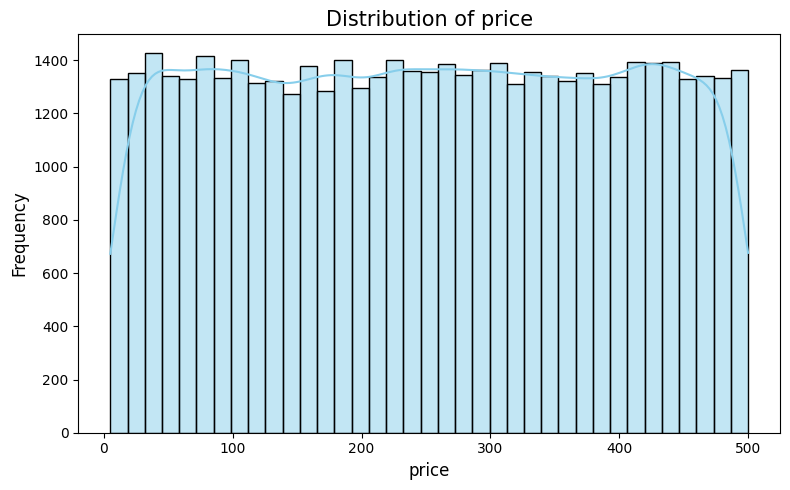

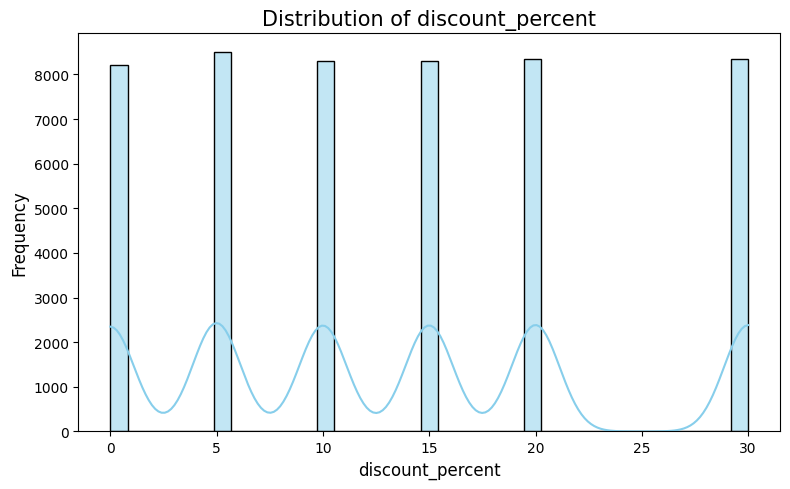

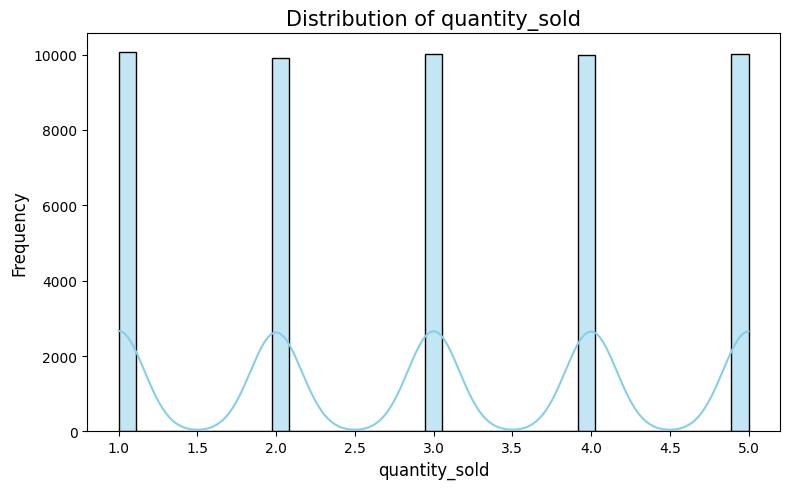

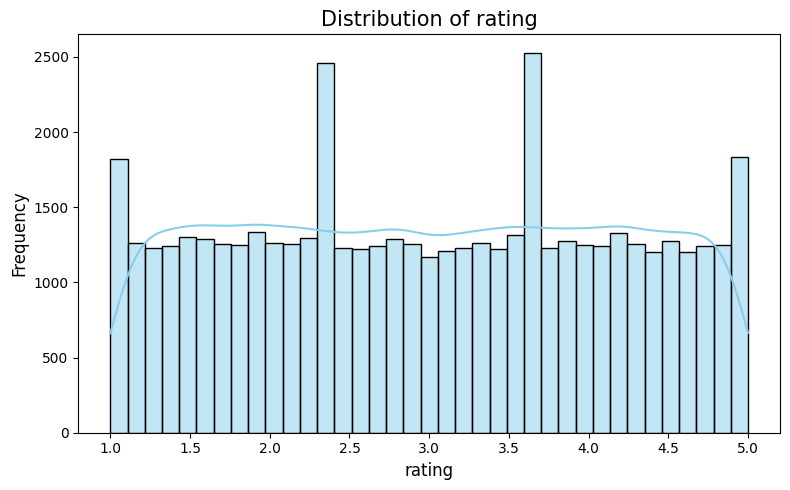

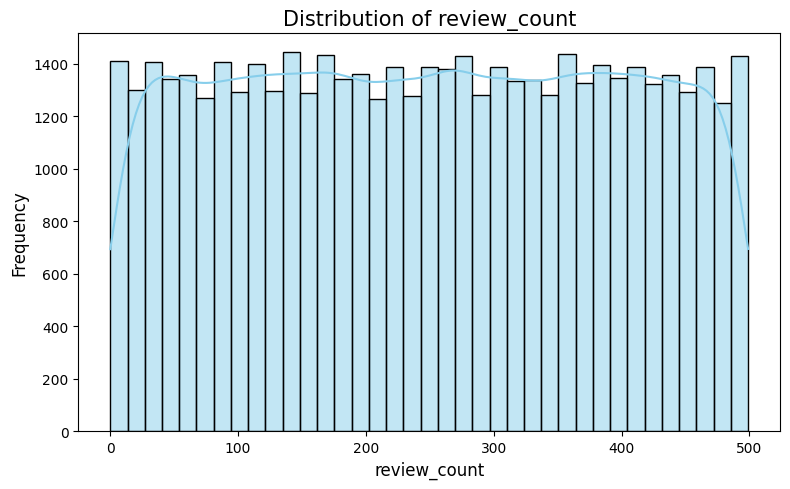

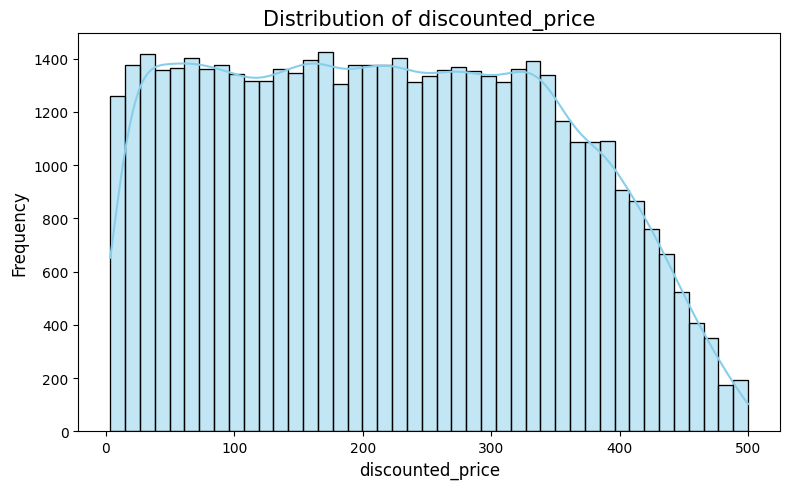

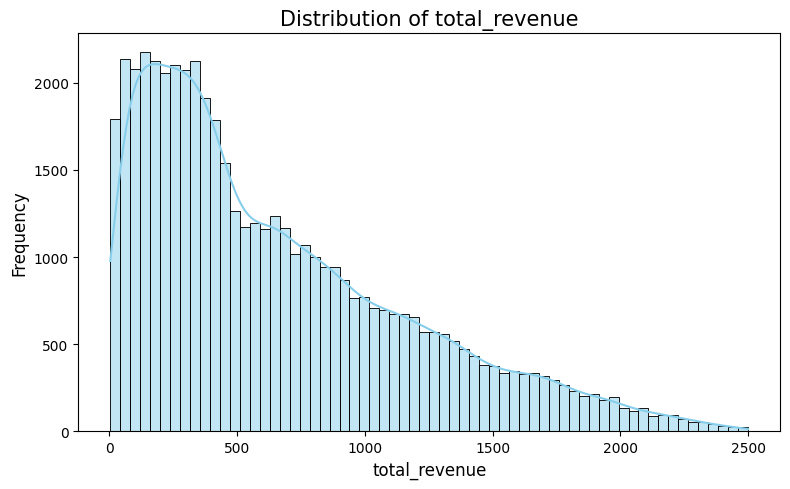

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(8, 5))

    sns.histplot(df[col], kde=True, color='skyblue', edgecolor='black')

    plt.title(f'Distribution of {col}', fontsize=15)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.tight_layout()

    plt.show()

# Most of the numeric columns are shown to be uniform
# But we can notice that the total revenue column to be heavly right skewed which shows that most orders bring in small amount of revenue and only a few are able to bring large amounts

/tmp/ipykernel_1175/1909825569.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


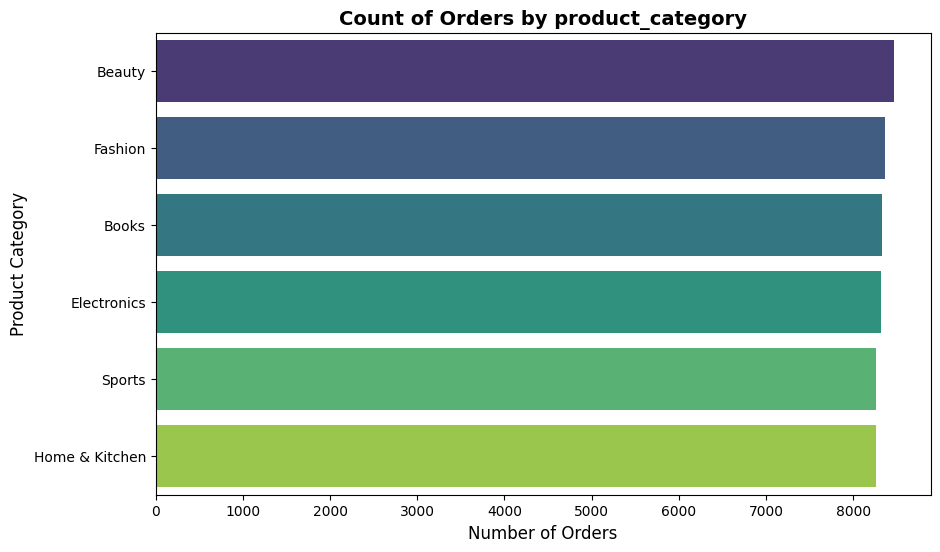

/tmp/ipykernel_1175/1909825569.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


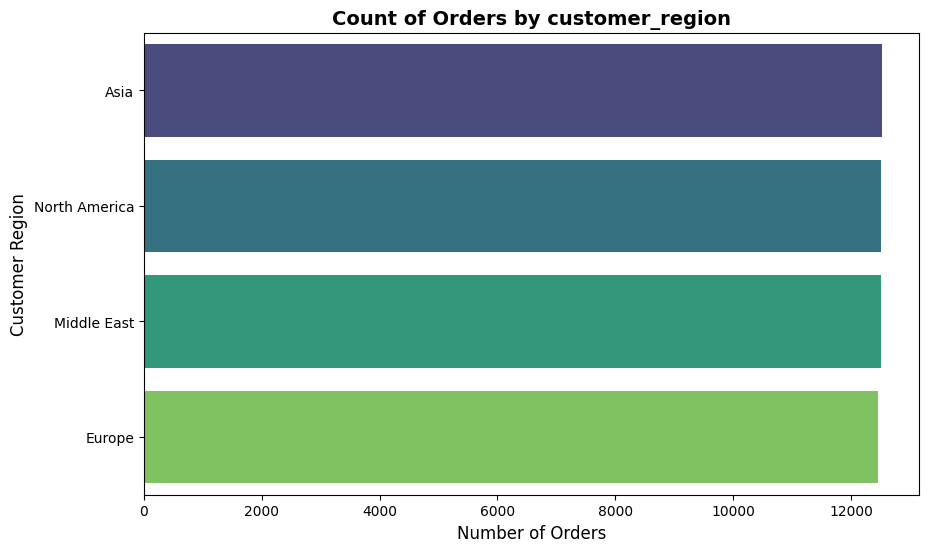

/tmp/ipykernel_1175/1909825569.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


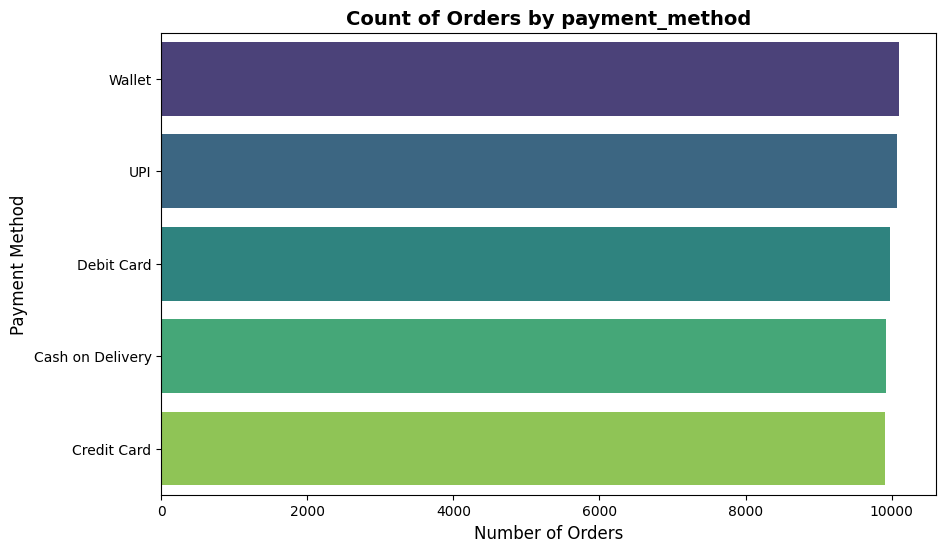

In [ ]:
for col in categorical_cols:
    if col == "order_date": continue
    plt.figure(figsize=(10, 6))

    sns.countplot(
        y=col,
        data=df,
        order=df[col].value_counts().index,
        palette='viridis'
    )

    plt.title(f'Count of Orders by {col}', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Orders', fontsize=12)
    plt.ylabel(col.replace('_', ' ').title(), fontsize=12)

    plt.show()

# Again most of the columns seem to be uniformly distributed but we can plot some bivarite analysis with the total_revenue column and also we can still break down the order_date column to try and see how the trends go


In [ ]:
print(df['order_date'].min())
print(df['order_date'].max())

2022-01-01
2023-12-31


In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])

df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month_name()

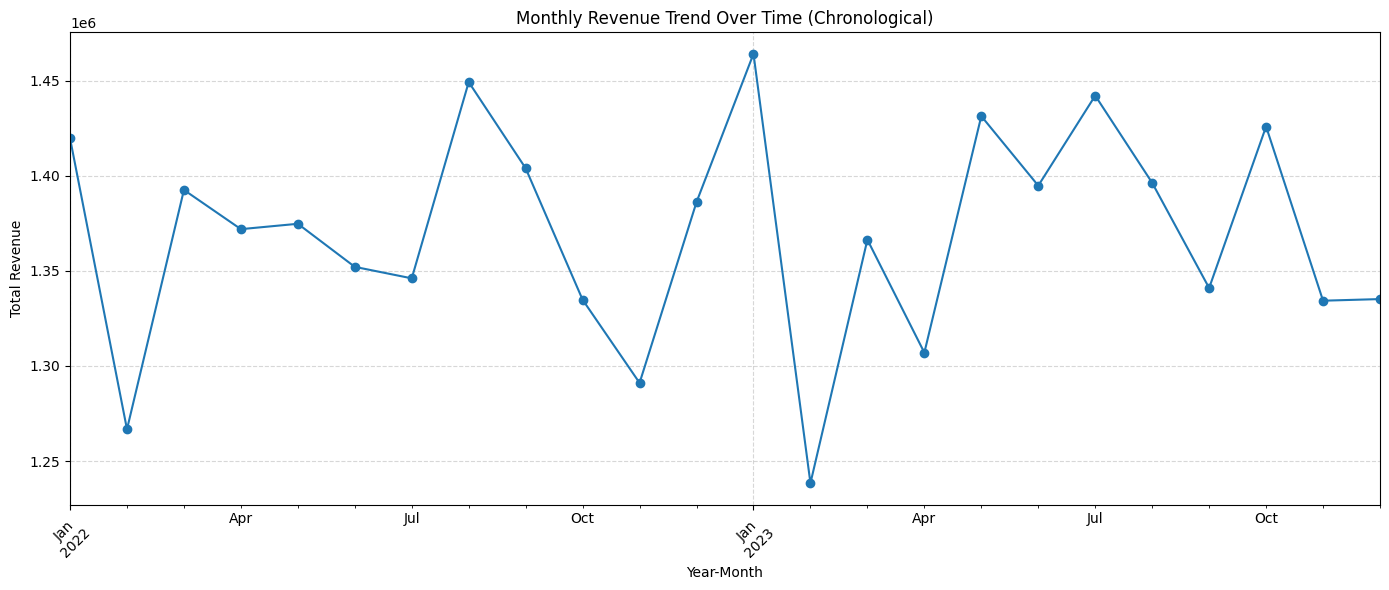

In [ ]:
chronological_revenue = df.groupby(
    df['order_date'].dt.to_period('M')
)['total_revenue'].sum().sort_index()

plt.figure(figsize=(14, 6))
chronological_revenue.plot(marker='o')

plt.title('Monthly Revenue Trend Over Time (Chronological)')
plt.xlabel('Year-Month')
plt.ylabel('Total Revenue')

plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# The plot highlights that we cannot see a stable trend over time or over special periods there some fluctuations between months and we can say that some months like January for example always had spikes


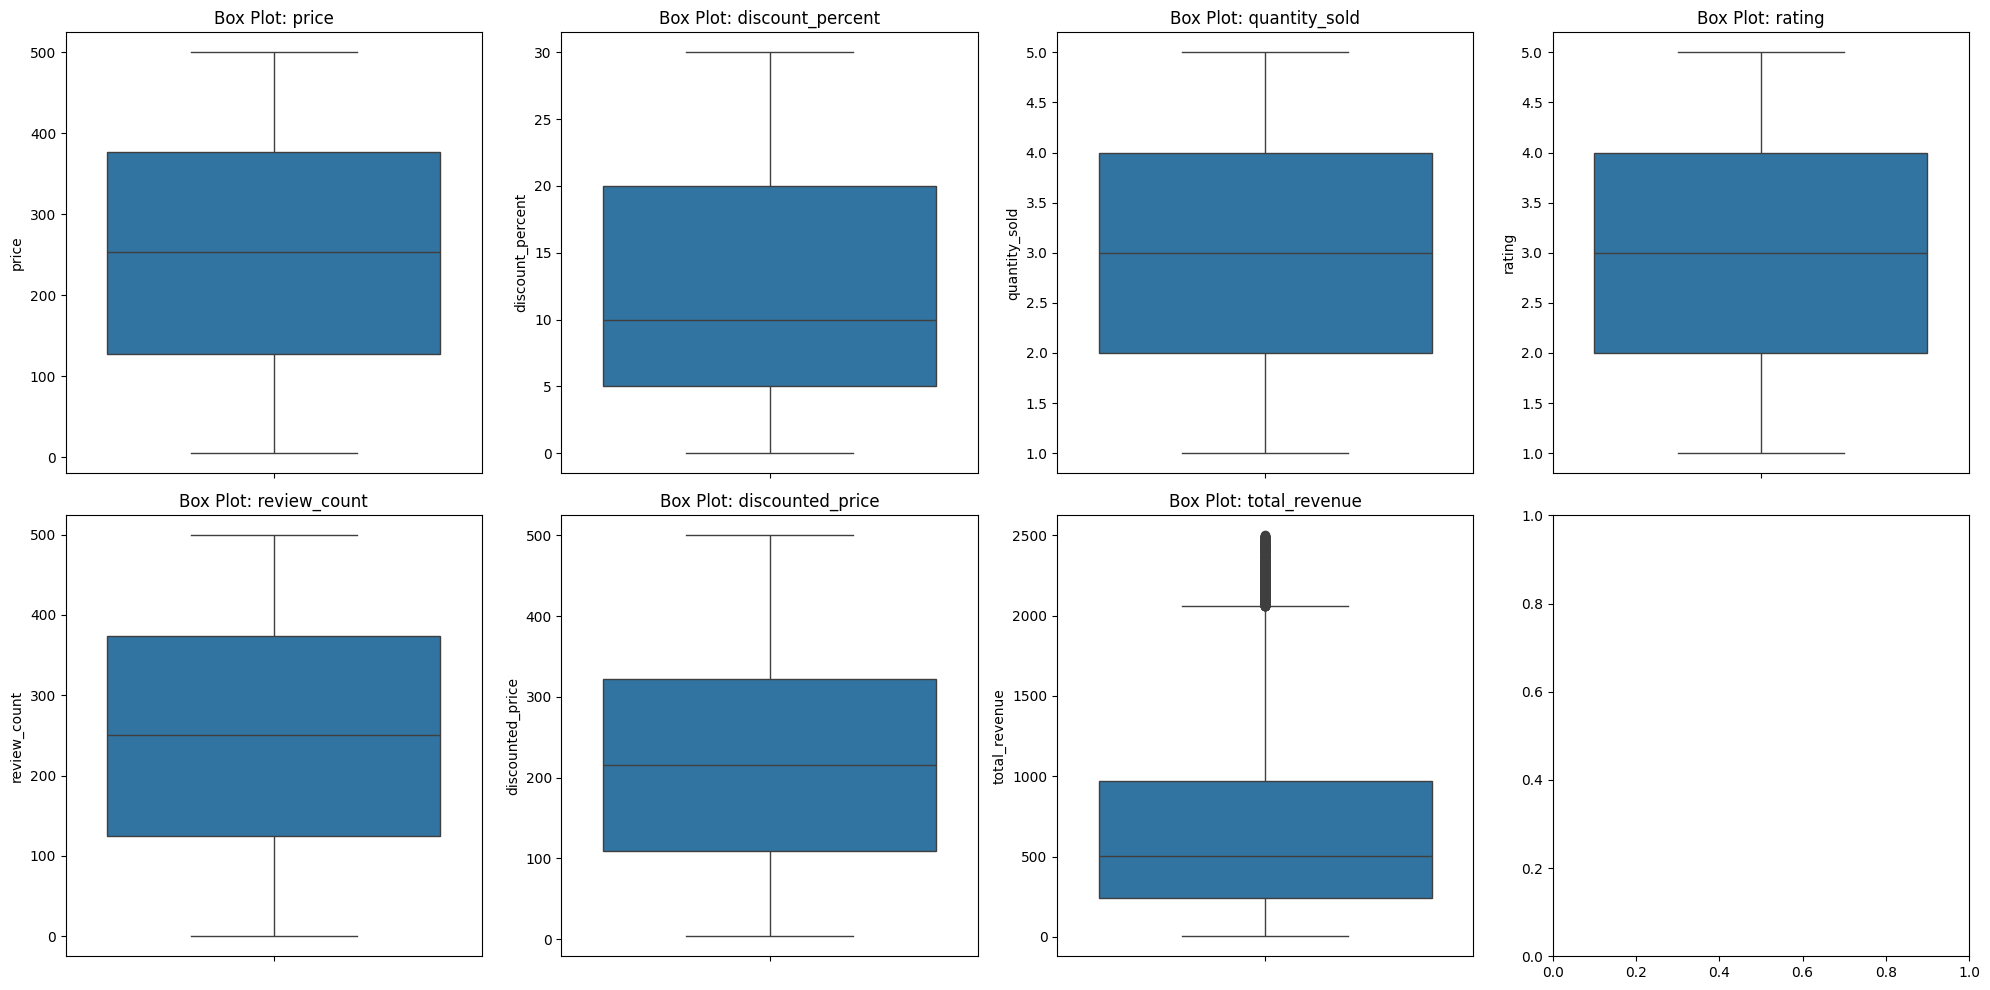

=== OUTLIER DETECTION (IQR Method) ===
price: 0 outliers (0.00%)
discount_percent: 0 outliers (0.00%)
quantity_sold: 0 outliers (0.00%)
rating: 0 outliers (0.00%)
review_count: 0 outliers (0.00%)
discounted_price: 0 outliers (0.00%)
total_revenue: 752 outliers (1.50%)


In [17]:
# Box plots for outlier detection
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, y=col, ax=axes[i])
    axes[i].set_title(f'Box Plot: {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Statistical outlier detection using IQR method
print("=== OUTLIER DETECTION (IQR Method) ===")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")

/tmp/ipykernel_1175/2611367326.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_rating.values, y=category_rating.index, palette='viridis')
/tmp/ipykernel_1175/2611367326.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_revenue.values, y=region_revenue.index, palette='Set2')


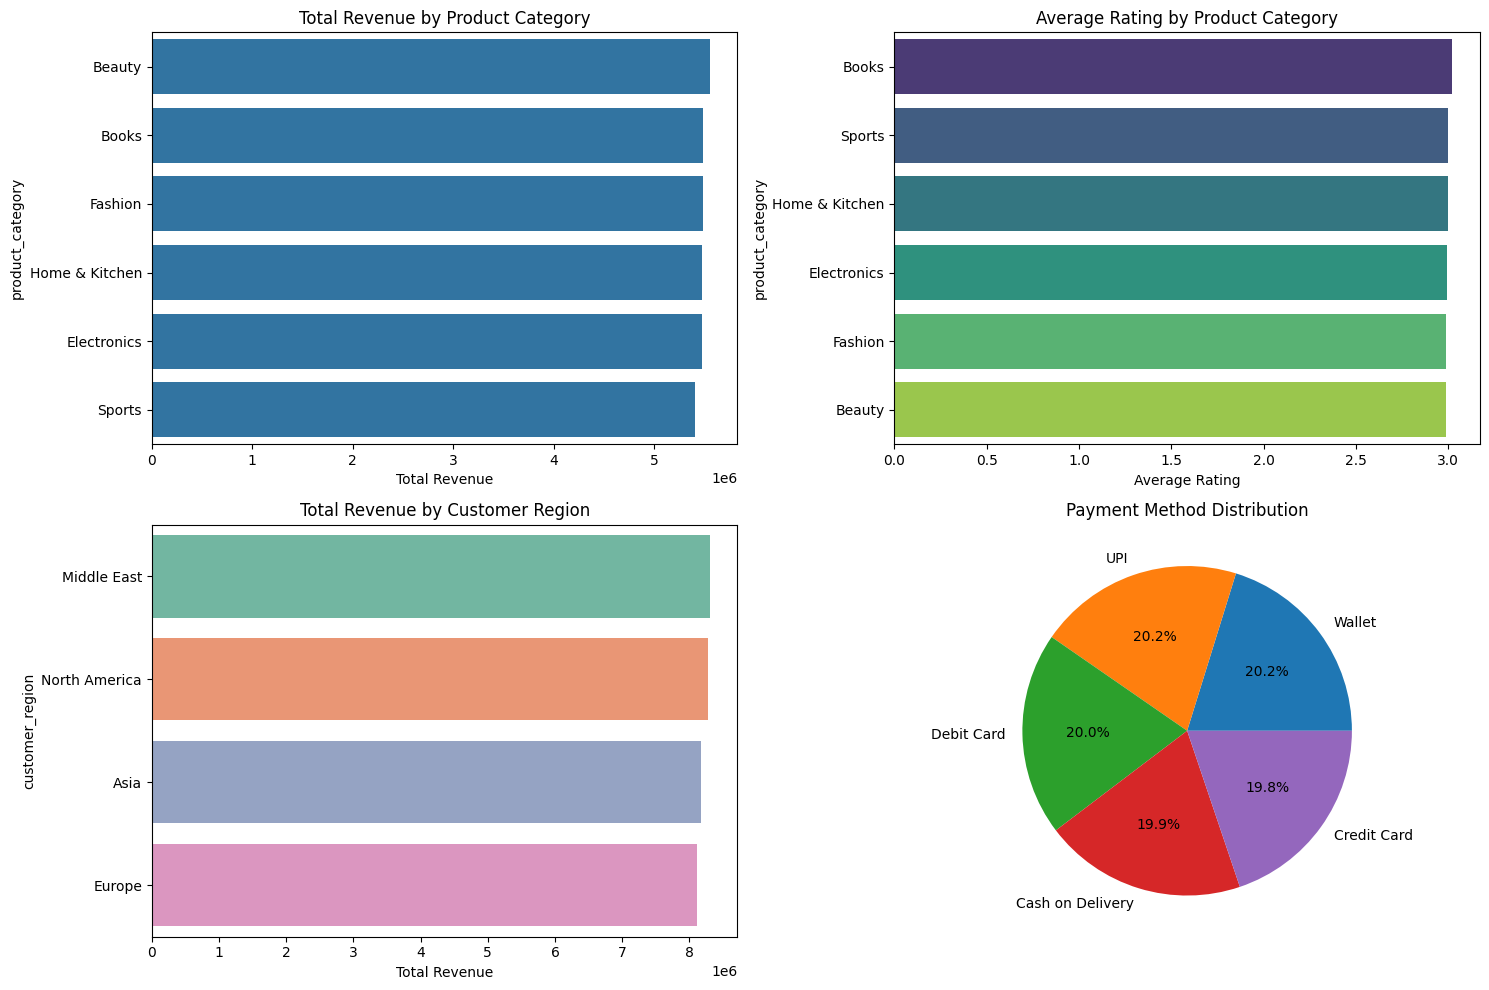

In [18]:
# Revenue analysis by category
plt.figure(figsize=(15, 10))

# Revenue by product category
plt.subplot(2, 2, 1)
category_revenue = df.groupby('product_category')['total_revenue'].sum().sort_values(ascending=False)
sns.barplot(x=category_revenue.values, y=category_revenue.index)
plt.title('Total Revenue by Product Category')
plt.xlabel('Total Revenue')

# Average rating by category
plt.subplot(2, 2, 2)
category_rating = df.groupby('product_category')['rating'].mean().sort_values(ascending=False)
sns.barplot(x=category_rating.values, y=category_rating.index, palette='viridis')
plt.title('Average Rating by Product Category')
plt.xlabel('Average Rating')

# Revenue by region
plt.subplot(2, 2, 3)
region_revenue = df.groupby('customer_region')['total_revenue'].sum().sort_values(ascending=False)
sns.barplot(x=region_revenue.values, y=region_revenue.index, palette='Set2')
plt.title('Total Revenue by Customer Region')
plt.xlabel('Total Revenue')

# Payment method distribution
plt.subplot(2, 2, 4)
payment_counts = df['payment_method'].value_counts()
plt.pie(payment_counts.values, labels=payment_counts.index, autopct='%1.1f%%')
plt.title('Payment Method Distribution')

plt.tight_layout()
plt.show()

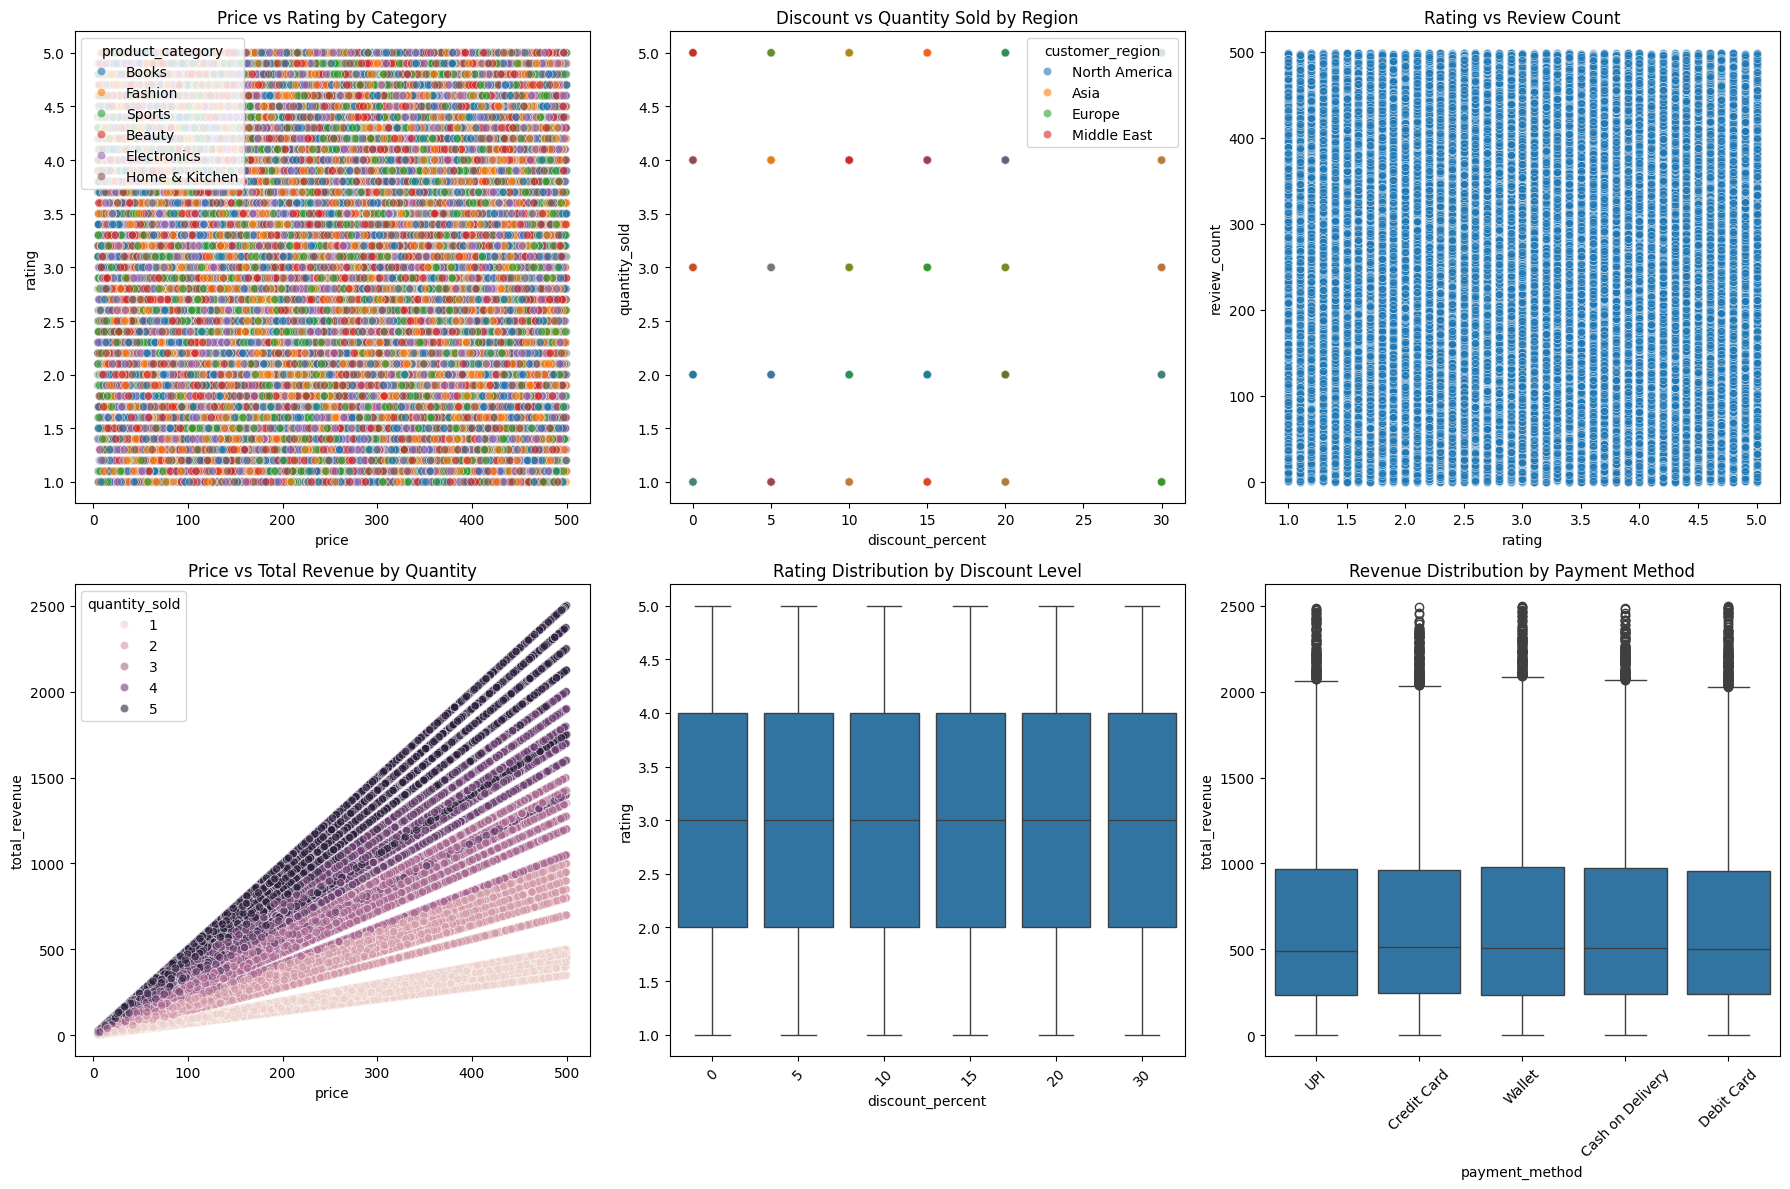

In [19]:
# Scatter plots for key relationships
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Price vs Rating
sns.scatterplot(data=df, x='price', y='rating', hue='product_category', ax=axes[0,0], alpha=0.6)
axes[0,0].set_title('Price vs Rating by Category')

# Discount vs Quantity Sold
sns.scatterplot(data=df, x='discount_percent', y='quantity_sold', hue='customer_region', ax=axes[0,1], alpha=0.6)
axes[0,1].set_title('Discount vs Quantity Sold by Region')

# Rating vs Review Count
sns.scatterplot(data=df, x='rating', y='review_count', ax=axes[0,2], alpha=0.6)
axes[0,2].set_title('Rating vs Review Count')

# Price vs Total Revenue
sns.scatterplot(data=df, x='price', y='total_revenue', hue='quantity_sold', ax=axes[1,0], alpha=0.6)
axes[1,0].set_title('Price vs Total Revenue by Quantity')

# Discount vs Rating
sns.boxplot(data=df, x='discount_percent', y='rating', ax=axes[1,1])
axes[1,1].set_title('Rating Distribution by Discount Level')
axes[1,1].tick_params(axis='x', rotation=45)

# Revenue by Payment Method
sns.boxplot(data=df, x='payment_method', y='total_revenue', ax=axes[1,2])
axes[1,2].set_title('Revenue Distribution by Payment Method')
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

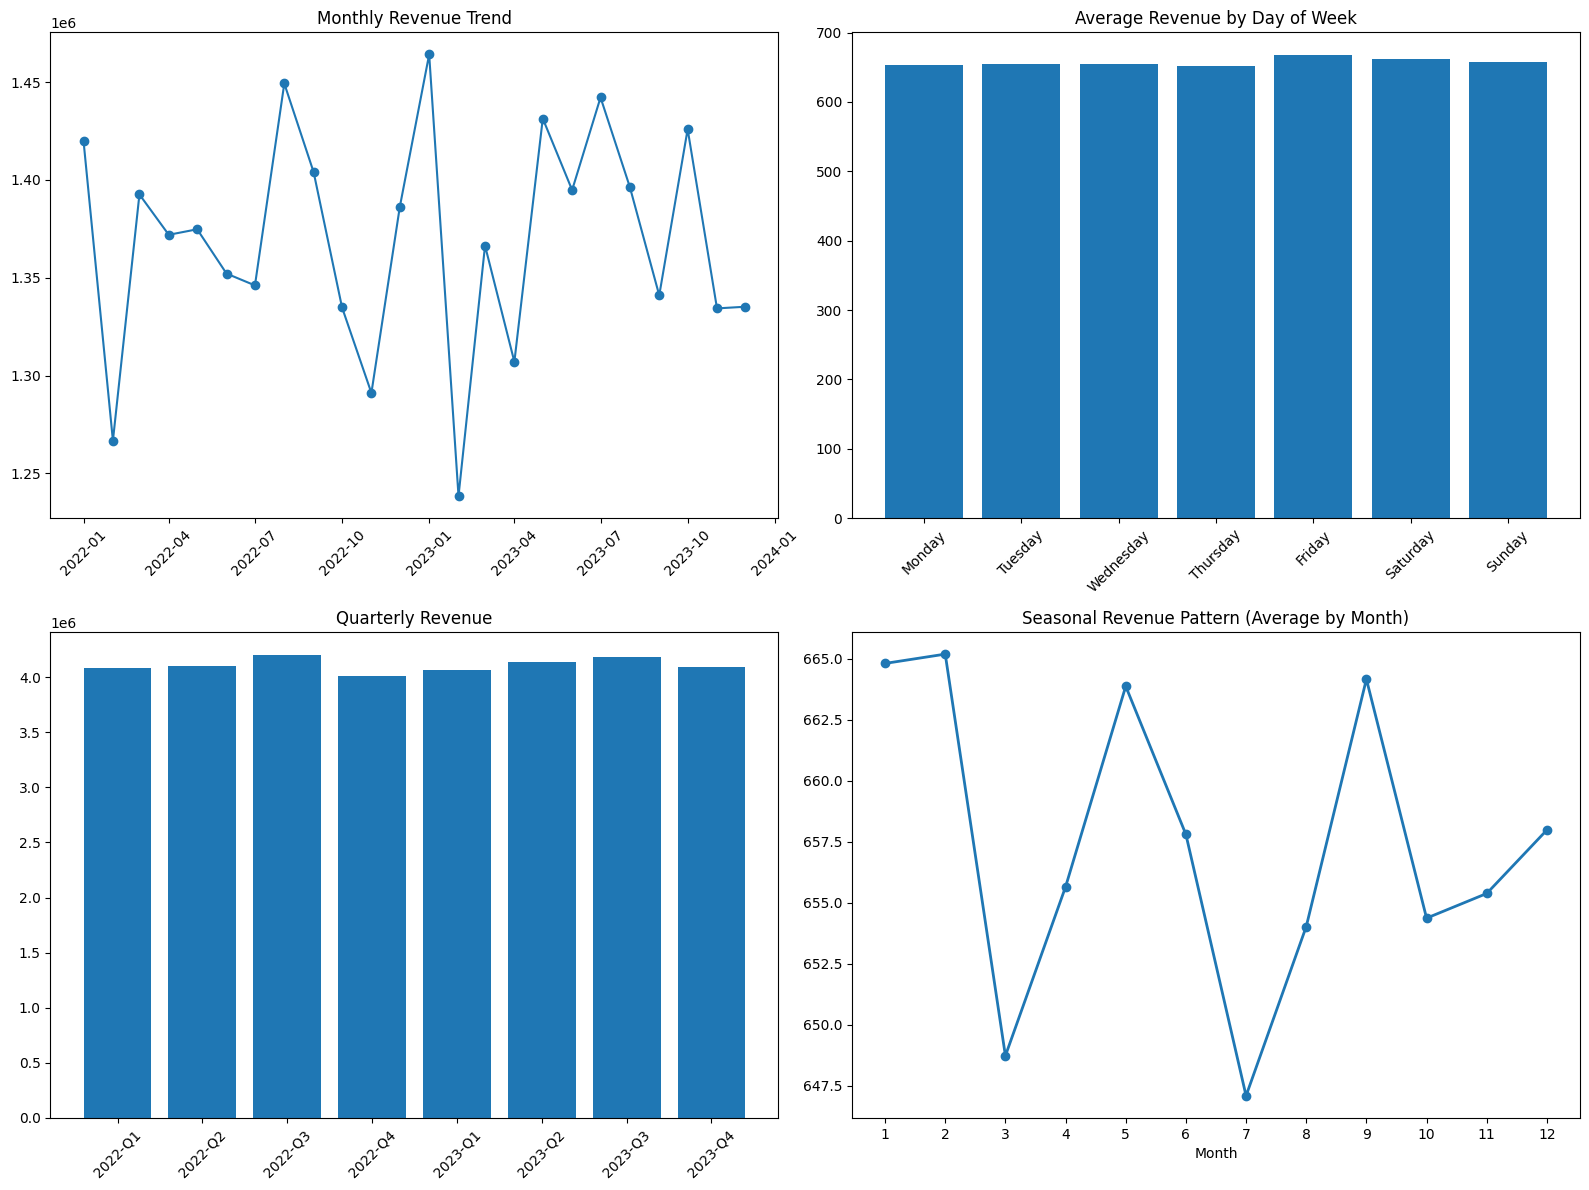

In [20]:
# Enhanced time series analysis
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['day_of_week'] = df['order_date'].dt.day_name()
df['quarter'] = df['order_date'].dt.quarter

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Monthly revenue trend
monthly_revenue = df.groupby(['year', 'month'])['total_revenue'].sum().reset_index()
monthly_revenue['date'] = pd.to_datetime(monthly_revenue[['year', 'month']].assign(day=1))
axes[0,0].plot(monthly_revenue['date'], monthly_revenue['total_revenue'], marker='o')
axes[0,0].set_title('Monthly Revenue Trend')
axes[0,0].tick_params(axis='x', rotation=45)

# Day of week analysis
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_revenue = df.groupby('day_of_week')['total_revenue'].mean().reindex(day_order)
axes[0,1].bar(dow_revenue.index, dow_revenue.values)
axes[0,1].set_title('Average Revenue by Day of Week')
axes[0,1].tick_params(axis='x', rotation=45)

# Quarterly analysis
quarterly_stats = df.groupby(['year', 'quarter']).agg({
    'total_revenue': 'sum',
    'rating': 'mean',
    'quantity_sold': 'sum'
}).reset_index()
quarterly_stats['period'] = quarterly_stats['year'].astype(str) + '-Q' + quarterly_stats['quarter'].astype(str)

axes[1,0].bar(quarterly_stats['period'], quarterly_stats['total_revenue'])
axes[1,0].set_title('Quarterly Revenue')
axes[1,0].tick_params(axis='x', rotation=45)

# Seasonal patterns
seasonal_revenue = df.groupby('month')['total_revenue'].mean()
axes[1,1].plot(seasonal_revenue.index, seasonal_revenue.values, marker='o', linewidth=2)
axes[1,1].set_title('Seasonal Revenue Pattern (Average by Month)')
axes[1,1].set_xlabel('Month')
axes[1,1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()